In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 1. PREPARAÇÃO DOS DADOS
energia_A = pd.read_csv('energia_202109-202112.csv', encoding='latin1')
energia_B = pd.read_csv('energia_202201-202212.csv', encoding='latin1')
meteo_A = pd.read_csv('meteo_202109-202112.csv', encoding='latin1')
meteo_B = pd.read_csv('meteo_202201-202212.csv', encoding='latin1')
energia = pd.concat([energia_A, energia_B], ignore_index=True)
meteo = pd.concat([meteo_A, meteo_B], ignore_index=True)

energia['timestamp'] = pd.to_datetime(energia['Data']) + pd.to_timedelta(energia['Hora'], unit='h')
meteo['dt_iso_clean'] = meteo['dt_iso'].str.replace(r' \+0000 UTC', '', regex=True)
meteo['timestamp'] = pd.to_datetime(meteo['dt_iso_clean'], format='%Y-%m-%d %H:%M:%S')

features_meteo = ['timestamp', 'temp', 'feels_like', 'temp_min', 'temp_max',
                  'pressure', 'humidity', 'wind_speed', 'rain_1h',
                  'clouds_all', 'weather_description']
df = pd.merge(energia, meteo[features_meteo], on='timestamp', how='left')
for col in ['temp','feels_like','temp_min','temp_max','pressure',
            'humidity','wind_speed','clouds_all']:
    df[col] = df[col].fillna(df[col].mean())
df['rain_1h'] = df['rain_1h'].fillna(0)
df['weather_description'] = df['weather_description'].fillna('missing')
df['Injeção na rede (kWh)'] = df['Injeção na rede (kWh)'].fillna('None')

df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
numericas = ['temp', 'feels_like', 'temp_min', 'temp_max', 'pressure', 'humidity', 'wind_speed', 'clouds_all']
imputer = KNNImputer(n_neighbors=5)
df[numericas] = imputer.fit_transform(df[numericas])

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
weather_ohe = ohe.fit_transform(df[['weather_description']])
weather_ohe_df = pd.DataFrame(weather_ohe, columns=ohe.get_feature_names_out(['weather_description']))
df = pd.concat([df, weather_ohe_df], axis=1)
scaler = StandardScaler()
df[numericas] = scaler.fit_transform(df[numericas])

le_target = LabelEncoder()
df['y'] = le_target.fit_transform(df['Injeção na rede (kWh)'])
target_names = [str(c) for c in le_target.classes_]

final_features = [
    'Normal (kWh)', 'Horário Económico (kWh)', 'Autoconsumo (kWh)'
] + numericas + ['hour', 'dayofweek', 'month', 'is_weekend'] + list(weather_ohe_df.columns)

X = df[final_features].values
y = df['y'].values

# 2. SPLIT E BALANCEAMENTO
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
smote = SMOTE(sampling_strategy='not majority', random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# 3. CLASS WEIGHTS MODERADOS
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_bal), y=y_train_bal)
cw_dict = dict(enumerate(class_weights))
none_idx = le_target.transform(['None'])[0]
medium_idx = le_target.transform(['Medium'])[0]
cw_dict[none_idx] *= 0.2     # penaliza "None" moderadamente
cw_dict[medium_idx] *= 0.7   # penaliza "Medium" moderadamente
for minor_class in ['Low', 'High', 'Very High']:
    minor_idx = le_target.transform([minor_class])[0]
    cw_dict[minor_idx] *= 1.5 # aumenta peso das minoritárias

# 4. MODELO MLP KERAS COM REGULARIZAÇÃO
n_classes = len(le_target.classes_)
model = Sequential([
    Input(shape=(X_train_bal.shape[1],)),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(96, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(n_classes, activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
es = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=2)

# 5. TREINO
history = model.fit(
    X_train_bal, y_train_bal,
    validation_data=(X_val, y_val),
    epochs=120,
    batch_size=64,
    callbacks=[es],
    verbose=2,
    class_weight=cw_dict
)

# 6. THRESHOLD TUNING NAS PROBABILIDADES (minoritárias >= 0.15)
y_val_pred_prob = model.predict(X_val)
minor_class_labels = ['Low', 'High', 'Very High']
minor_class_indices = [le_target.transform([lbl])[0] for lbl in minor_class_labels]
val_preds = []
for i, probs in enumerate(y_val_pred_prob):
    minor_probs = [probs[j] for j in minor_class_indices]
    if max(minor_probs) > 0.15:
        val_preds.append(minor_class_indices[np.argmax(minor_probs)])
    else:
        val_preds.append(np.argmax(probs))
y_val_pred = np.array(val_preds)

print("Accuracy val:", accuracy_score(y_val, y_val_pred))
print(classification_report(y_val, y_val_pred, target_names=target_names))
print(confusion_matrix(y_val, y_val_pred))

# 7. TESTE E SUBMISSÃO
energia_test = pd.read_csv('energia_202301-202304.csv', encoding='latin1')
meteo_test = pd.read_csv('meteo_202301-202304.csv', encoding='latin1')
energia_test['timestamp'] = pd.to_datetime(energia_test['Data']) + pd.to_timedelta(energia_test['Hora'], unit='h')
meteo_test['dt_iso_clean'] = meteo_test['dt_iso'].str.replace(r' \+0000 UTC', '', regex=True)
meteo_test['timestamp'] = pd.to_datetime(meteo_test['dt_iso_clean'], format='%Y-%m-%d %H:%M:%S')
df_test = pd.merge(energia_test, meteo_test[features_meteo], on='timestamp', how='left')
for col in numericas:
    df_test[col] = df_test[col].fillna(df[col].mean())
df_test['rain_1h'] = df_test['rain_1h'].fillna(0)
df_test['weather_description'] = df_test['weather_description'].fillna('missing')
df_test['hour'] = df_test['timestamp'].dt.hour
df_test['dayofweek'] = df_test['timestamp'].dt.dayofweek
df_test['month'] = df_test['timestamp'].dt.month
df_test['is_weekend'] = (df_test['dayofweek'] >= 5).astype(int)
df_test[numericas] = imputer.transform(df_test[numericas])
df_test.loc[~df_test['weather_description'].isin(ohe.categories_[0]), 'weather_description'] = 'missing'
weather_ohe_test = ohe.transform(df_test[['weather_description']])
weather_ohe_df_test = pd.DataFrame(weather_ohe_test, columns=ohe.get_feature_names_out(['weather_description']))
df_test = pd.concat([df_test, weather_ohe_df_test], axis=1)
df_test[numericas] = scaler.transform(df_test[numericas])
X_test = df_test[final_features].values

y_pred_test_prob = model.predict(X_test)
test_preds = []
for probs in y_pred_test_prob:
    minor_probs = [probs[j] for j in minor_class_indices]
    if max(minor_probs) > 0.15:
        test_preds.append(minor_class_indices[np.argmax(minor_probs)])
    else:
        test_preds.append(np.argmax(probs))
y_pred_test = np.array(test_preds)
labels_pred = le_target.inverse_transform(y_pred_test)

dummy = pd.read_csv('dummy_submission.csv')
assert len(dummy) == len(labels_pred), "Número de linhas do ficheiro dummy diferente do número de previsões!"
dummy['Result'] = labels_pred
dummy.to_csv('submission.csv', index=False)


Epoch 1/120
487/487 - 3s - 5ms/step - accuracy: 0.4919 - loss: 1.2207 - val_accuracy: 0.5776 - val_loss: 1.1043
Epoch 2/120
487/487 - 0s - 915us/step - accuracy: 0.5923 - loss: 0.9032 - val_accuracy: 0.6443 - val_loss: 0.9017
Epoch 3/120
487/487 - 0s - 965us/step - accuracy: 0.6424 - loss: 0.7819 - val_accuracy: 0.6838 - val_loss: 0.8133
Epoch 4/120
487/487 - 1s - 1ms/step - accuracy: 0.6766 - loss: 0.7124 - val_accuracy: 0.7368 - val_loss: 0.6444
Epoch 5/120
487/487 - 1s - 1ms/step - accuracy: 0.6935 - loss: 0.6854 - val_accuracy: 0.7391 - val_loss: 0.6863
Epoch 6/120
487/487 - 1s - 1ms/step - accuracy: 0.7087 - loss: 0.6497 - val_accuracy: 0.7577 - val_loss: 0.6596
Epoch 7/120
487/487 - 1s - 1ms/step - accuracy: 0.7209 - loss: 0.6275 - val_accuracy: 0.7668 - val_loss: 0.6356
Epoch 8/120
487/487 - 0s - 1ms/step - accuracy: 0.7290 - loss: 0.6105 - val_accuracy: 0.7795 - val_loss: 0.5866
Epoch 9/120
487/487 - 0s - 983us/step - accuracy: 0.7336 - loss: 0.6006 - val_accuracy: 0.7917 - val

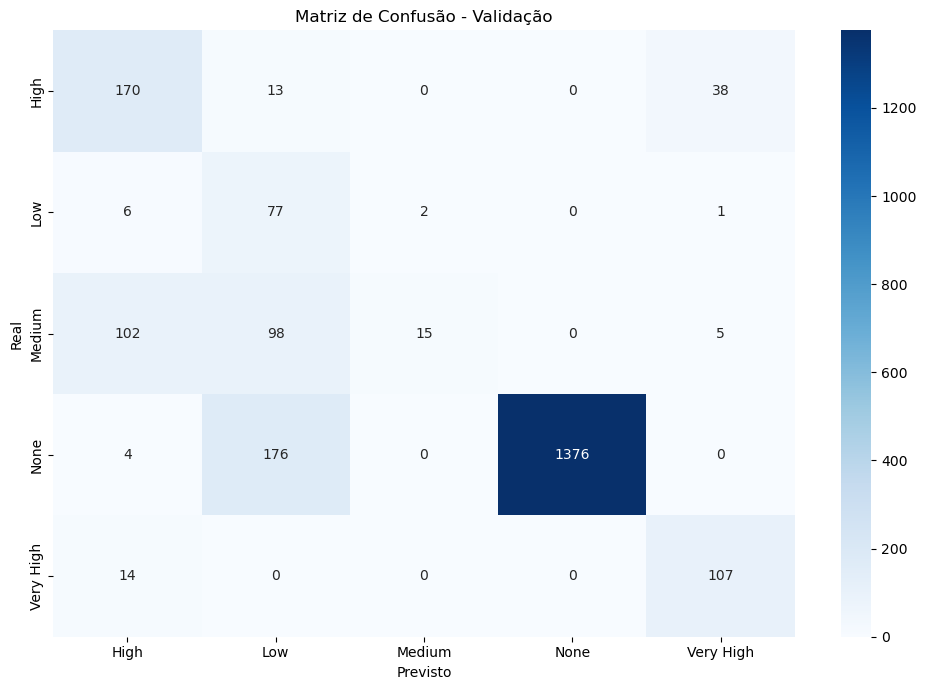

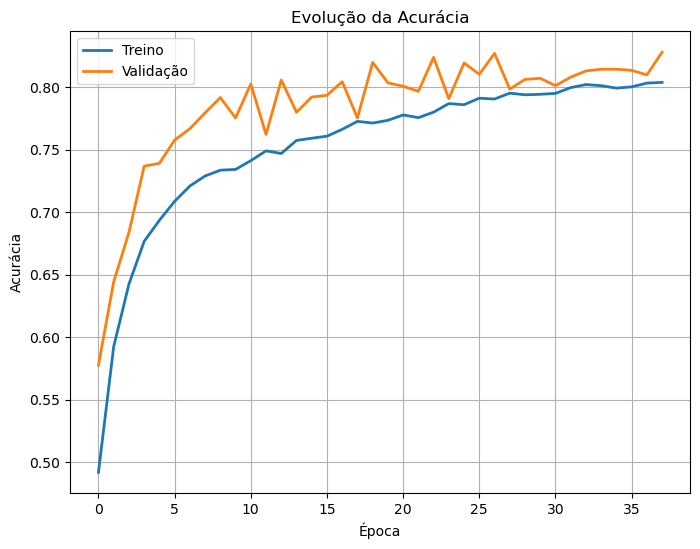

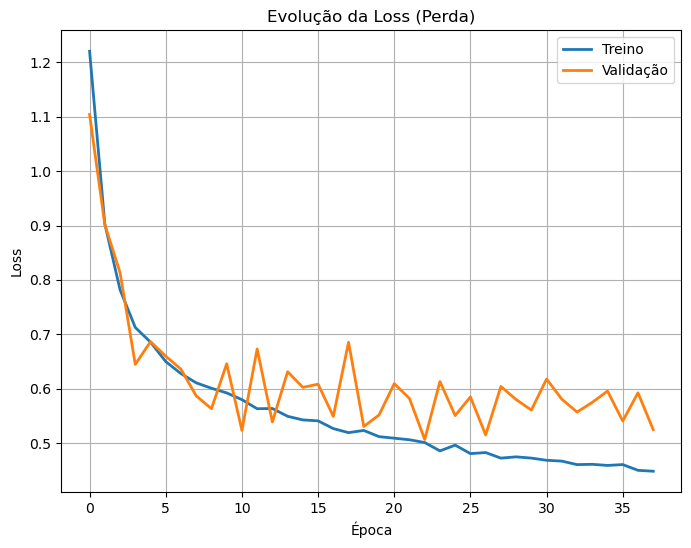

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title("Matriz de Confusão - Validação")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Treino', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validação', linewidth=2)
plt.title('Evolução da Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Treino', linewidth=2)
plt.plot(history.history['val_loss'], label='Validação', linewidth=2)
plt.title('Evolução da Loss (Perda)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
Modelo: Keras com SMOTE e class_weights e EarlyStopping
Aprende bem as classes principais e começa a captar padrões nas minoritárias, Very High tem pouco acertos
Não há overfitting